# Curvas de tiempo trayecto

## Índice<a id="0-índice"></a>
1. [Modelo de velocidades](#1-modelo)
2. [Tiempos de arribo](#2-tiempos)
3. [Trayectorias de rayos](#3-rayos)
4. [Visualización](#4-visuales)
5. [Ejercicios](#5-ejercicios)

## 1. Modelo de velocidades <a id="1-modelo"></a>

Los modelos de velocidades 1D permiten calcular tiempos de arribo teóricos para distintas fases en un medio esféricamente simétrico. También hacen posible representar trayectorias de propagación y ubicar los puntos de intersección con discontinuidades internas del modelo.

Tenemos que escoger un modelo de velocidades. En TauPy, los modelos disponibles son los siguientes:
- `1066a` y `1066b`
- `ak135`
- `iasp91`
- `prem`,
entre otros

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from obspy import read, read_inventory, UTCDateTime
from obspy.taup import TauPyModel


In [21]:
model = TauPyModel(model='iasp91')

[Volver al índice](#0-índice)

## 2. Tiempos de arribo <a id="2-tiempos"></a>

El método principal para calcular los tiempos de arribo en los modelos es `get_travel_times()`. Su uso básico requiere únicamente la profundidad del evento y la distancia epicentral en grados, pero también permite mayor flexibilidad al especificar fases particulares, la profundidad del instrumento o incluso el modelo de referencia. Por defecto, devuelve los arribos de varias fases, y estos pueden visualizarse directamente con `print()`.

In [3]:
arribos = model.get_travel_times(source_depth_in_km=10,distance_in_degree=3,phase_list=('ttbasic',))
print(arribos)

38 arrivals
	P phase arrival at 47.579 seconds
	Pn phase arrival at 47.581 seconds
	pP phase arrival at 49.980 seconds
	sP phase arrival at 51.486 seconds
	P phase arrival at 53.503 seconds
	P phase arrival at 53.707 seconds
	pP phase arrival at 55.075 seconds
	PP phase arrival at 55.100 seconds
	pP phase arrival at 55.325 seconds
	PP phase arrival at 56.639 seconds
	sP phase arrival at 56.839 seconds
	sP phase arrival at 57.072 seconds
	p phase arrival at 57.488 seconds
	P phase arrival at 57.639 seconds
	PP phase arrival at 57.915 seconds
	pP phase arrival at 58.076 seconds
	PP phase arrival at 58.672 seconds
	sP phase arrival at 59.933 seconds
	sP phase arrival at 60.271 seconds
	S phase arrival at 84.492 seconds
	Sn phase arrival at 84.500 seconds
	sS phase arrival at 88.444 seconds
	S phase arrival at 92.657 seconds
	S phase arrival at 93.013 seconds
	sS phase arrival at 95.327 seconds
	sS phase arrival at 95.765 seconds
	s phase arrival at 99.236 seconds
	S phase arrival at 99.49

In [22]:
arribo = arribos[0]

In [5]:
arribo.time

47.578738226886315

In [6]:
print(f'Fase: {arribo.name}')
print(f'Distancia: {arribo.distance} grados')
print(f'Tiempo de arribo: {arribo.time} segundos')
print(f'Parámetro de rayo: {arribo.ray_param} segundos/radianes')
print(f'Ángulo de despegue: {arribo.takeoff_angle} grados')
print(f'Ángulo de incidencia: {arribo.incident_angle} grados')

Fase: P
Distancia: 3 grados
Tiempo de arribo: 47.578738226886315 segundos
Parámetro de rayo: 787.8793087854699 segundos/radianes
Ángulo de despegue: 45.92198985351952 grados
Ángulo de incidencia: 45.829193329481626 grados


La nomenclatura para las fases es la siguiente:
- `P`: onda P (compresiva), ya sea hacia arriba (la corteza) o hacia abajo (el interior de la Tierra), en la corteza o manto.
- `p`: onda P, exclusivamente hacia arriba, en la corteza o manto.
- `S`: onda S (cizalla), hacia arriba o hacia abajo, en la corteza o manto.
- `s`: onda S, exclusivamente hacia arriba, en la corteza o manto.
- `K`: onda P en el núcleo externo.
- `I`: onda P en el núcleo interno.
- `J`: onda S en el núcleo interno.

Y los modificadores:
- `m`: interacción con la discontinuidad de Moho (límite corteza-manto)
- `n`: una «onda de cabeza» (*head wave*). Esta onda viaja siguiendo la discontinuidad de Moho. Se da exclusivamente cuando el ángulo de incidencia de la onda supera el ángulo crítico (el ángulo para el cual el ángulo de la onda refractada es $\pi/2$ o 90 grados)
$$\frac{\sin(\theta_1)}{v_1} = \frac{\sin(\theta_2)}{v_2}\Rightarrow\frac{\sin(i_c)}{v_1} = \frac{\sin(\pi/2)}{v_2}$$

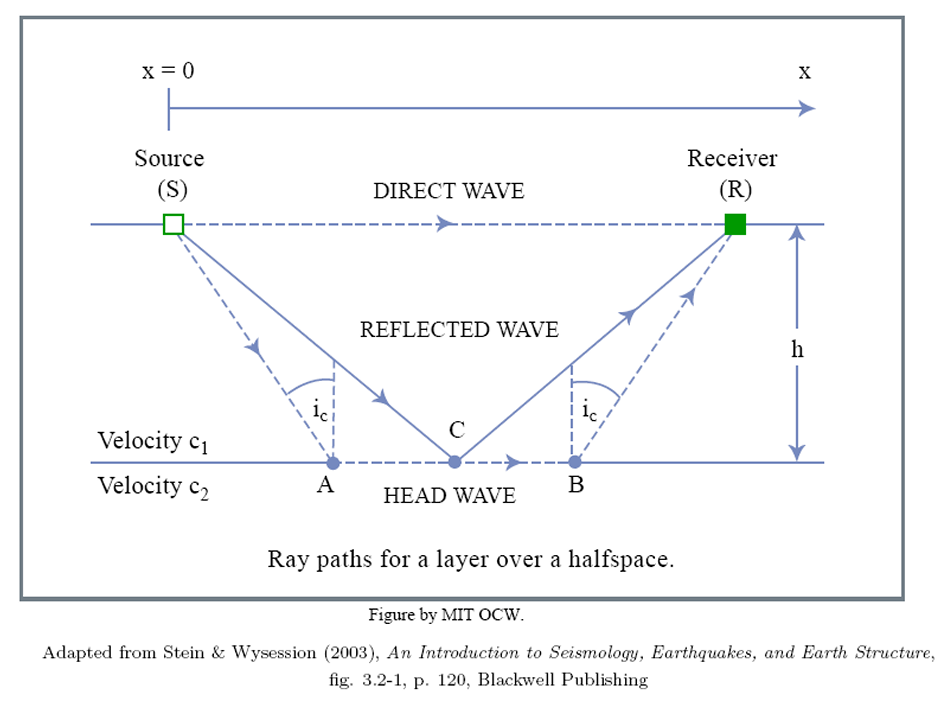
- `c`: reflexión (por encima) en el límite manto-núcleo
- `i`: reflexión (por encima) en el límite núcleo interno-núcleo externo
- `^`: reflexión (por debajo)
- `v`: reflexión (por encima)
- `diff`: una onda difractada a lo largo del límite manto-núcleo.
- `ed`: una onda que exclusivamente va hacia abajo.


Se puede específicamente preguntar por una fase en específico (por ejemplo, `P` o `S`):

In [7]:
arribos = model.get_travel_times(source_depth_in_km = 10,
                                 distance_in_degree = 3, 
                                 phase_list = ['P', 'S'])
print(arribos)

8 arrivals
	P phase arrival at 47.579 seconds
	P phase arrival at 53.503 seconds
	P phase arrival at 53.707 seconds
	P phase arrival at 57.639 seconds
	S phase arrival at 84.492 seconds
	S phase arrival at 92.657 seconds
	S phase arrival at 93.013 seconds
	S phase arrival at 99.496 seconds


Alternativamente, si tenemos coordenadas exactas del epicentro y de la estación, podemos usar la función `get_travel_times_geo()`. 

Como ejemplo, tomemos las coordenadas del último terremoto con magnitud mayor a 7 registrado en México (19S-2022, 61 km al sur de Coalcomán, Mich.)
- Latitud: 18.2377 grados
- Longitud: -103.269 grados
- Profundidad: 12 kilómetros
Nuestra estación será "El Pozo" (PZIG o G.UNM), una estación de banda ancha en Ciudad Universitaria.
- Latitud: 19.329
- Longitud: -99.178

In [23]:
arribos2 = model.get_travel_times_geo(source_depth_in_km=12,
                                      source_latitude_in_deg=18.2377,
                                      source_longitude_in_deg=-103.269,
                                      receiver_latitude_in_deg=19.329,
                                      receiver_longitude_in_deg=-99.178,
                                      phase_list=['P','S'])

In [24]:
print(arribos2)

10 arrivals
	P phase arrival at 61.415 seconds
	P phase arrival at 70.799 seconds
	P phase arrival at 70.912 seconds
	P phase arrival at 77.081 seconds
	P phase arrival at 77.144 seconds
	S phase arrival at 109.407 seconds
	S phase arrival at 122.642 seconds
	S phase arrival at 122.838 seconds
	S phase arrival at 133.057 seconds
	S phase arrival at 133.165 seconds


[Volver al índice](#0-índice)

## 3. Trayectorias de rayos <a id="3-rayos"></a>

Si queremos calcular la trayectoria que siguen los rayos, los cuales son vectores perpendiculares a los frentes de onda, se utiliza la función `get_ray_paths()`. Esta devuelve un arreglo de registros de NumPy con información como el parámetro de rayo, el tiempo, la distancia y la profundidad, y emplea los mismos argumentos que `get_travel_times()`.

In [10]:
arribos = model.get_ray_paths(source_depth_in_km=10, distance_in_degree=3)
arribos[0].path

array([(787.86184132, 0.00000000e+00, 0.00000000e+00, 1.00000000e+01),
       (787.86184132, 6.69443452e-04, 4.38499745e-07, 1.00027011e+01),
       (787.86184132, 1.24007686e+00, 8.12915704e-04, 1.50013505e+01),
       (787.86184132, 2.48052755e+00, 1.62735683e-03, 2.00000000e+01),
       (787.86184132, 2.72442293e+00, 1.82866447e-03, 2.09375000e+01),
       (787.86184132, 2.96838531e+00, 2.03008687e-03, 2.18750000e+01),
       (787.86184132, 3.45651139e+00, 2.43327647e-03, 2.37500000e+01),
       (787.86184132, 4.43357123e+00, 3.24103851e-03, 2.75000000e+01),
       (787.86184132, 6.39094089e+00, 4.86212323e-03, 3.50000000e+01),
       (787.86184132, 1.77497992e+01, 1.92761023e-02, 3.63273253e+01),
       (787.86184132, 2.25511562e+01, 2.53701734e-02, 3.64558544e+01),
       (787.86184132, 2.73525132e+01, 3.14642445e-02, 3.63273253e+01),
       (787.86184132, 3.87113715e+01, 4.58782236e-02, 3.50000000e+01),
       (787.86184132, 4.06687411e+01, 4.74993083e-02, 2.75000000e+01),
      

[Volver al índice](#0-índice)

## 4. Visualización <a id="4-visuales"></a>
Se pueden graficar de manera simple: 

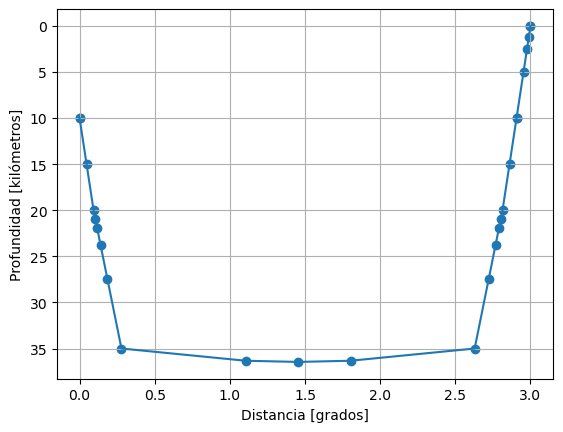

In [11]:
tiempo = [arribos[0].path[i][1] for i in range(arribos[0].path.shape[0])]
distancia = [(180/np.pi) * arribos[0].path[i][2] for i in range(arribos[0].path.shape[0])]
profundidad = [arribos[0].path[i][3] for i in range(arribos[0].path.shape[0])]

fig = plt.figure()
ax = plt.subplot(111)
ax.grid()
ax.plot(distancia,profundidad)
ax.scatter(distancia,profundidad)
ax.set_xlabel('Distancia [grados]')
ax.set_ylabel('Profundidad [kilómetros]')
ax.invert_yaxis()

Pero en Obspy se pueden graficar las fases de la siguiente forma:

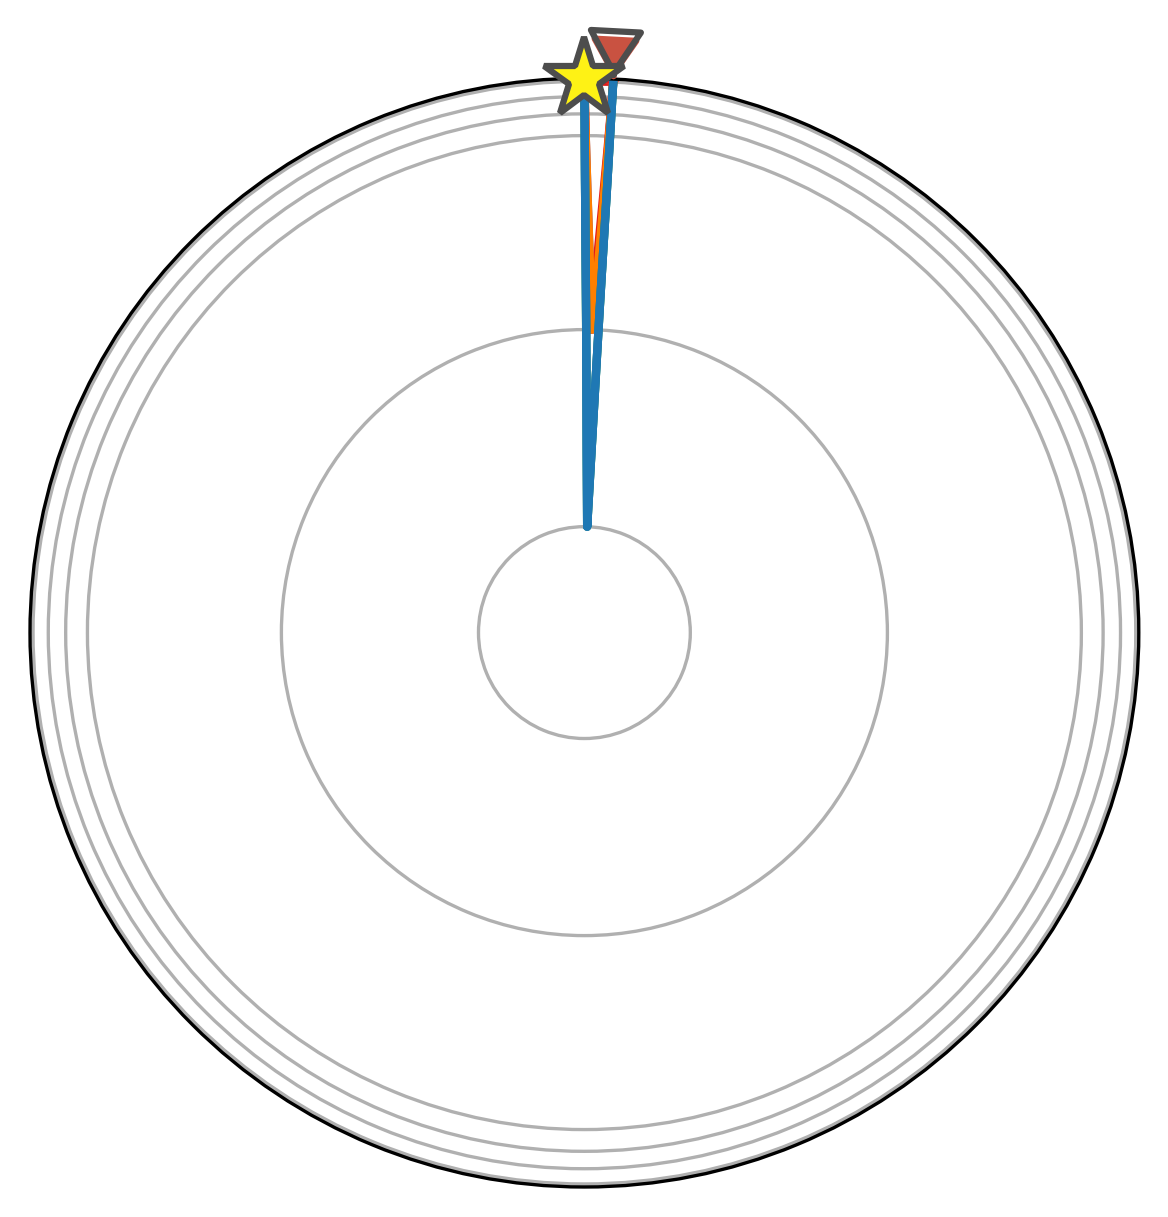

In [12]:
# ttbasic
arribos = model.get_ray_paths(source_depth_in_km=10, distance_in_degree=3, phase_list=['ttbasic'])
fig = plt.figure(dpi=300)
arribos.plot_rays(plot_all=False,show=False,fig=fig)
plt.show()

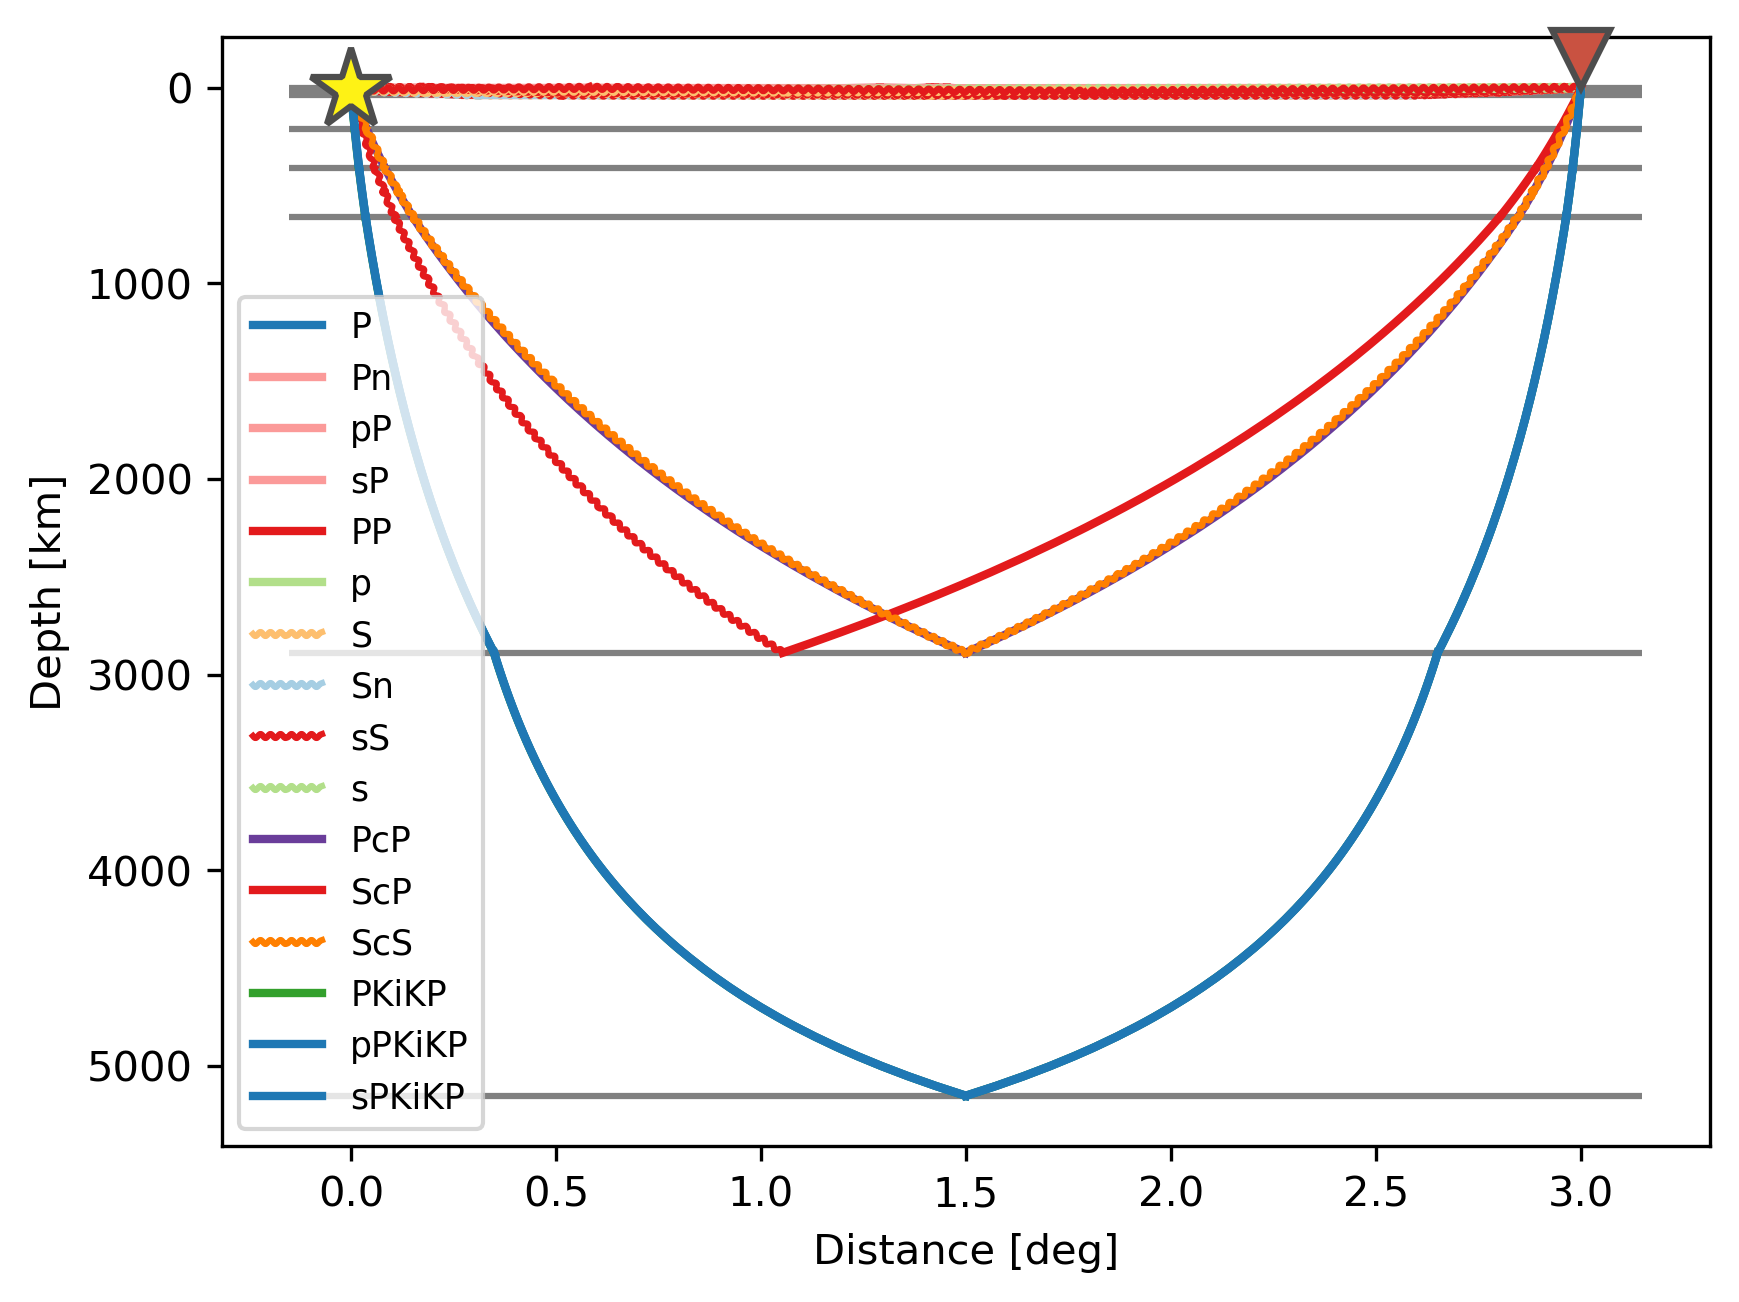

In [13]:
arribos = model.get_ray_paths(source_depth_in_km=10, distance_in_degree=3, phase_list=['ttbasic'])
fig = plt.figure(dpi=300)
arribos.plot_rays(plot_type="cartesian",plot_all=False,show=False,fig=fig,legend=True,indicate_wave_type=True)
plt.show()

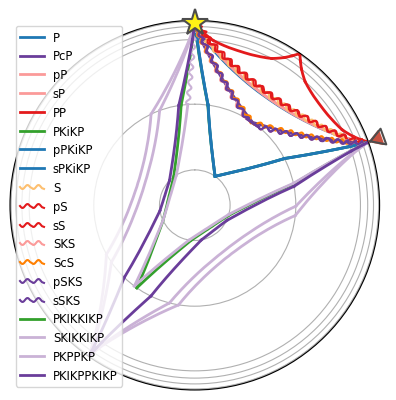

In [14]:
arribos = model.get_ray_paths(source_depth_in_km=90, distance_in_degree=70, phase_list=['ttbasic'])
fig = plt.figure(dpi=100)
arribos.plot_rays(show=False,fig=fig,legend=True,indicate_wave_type=True)
plt.show()

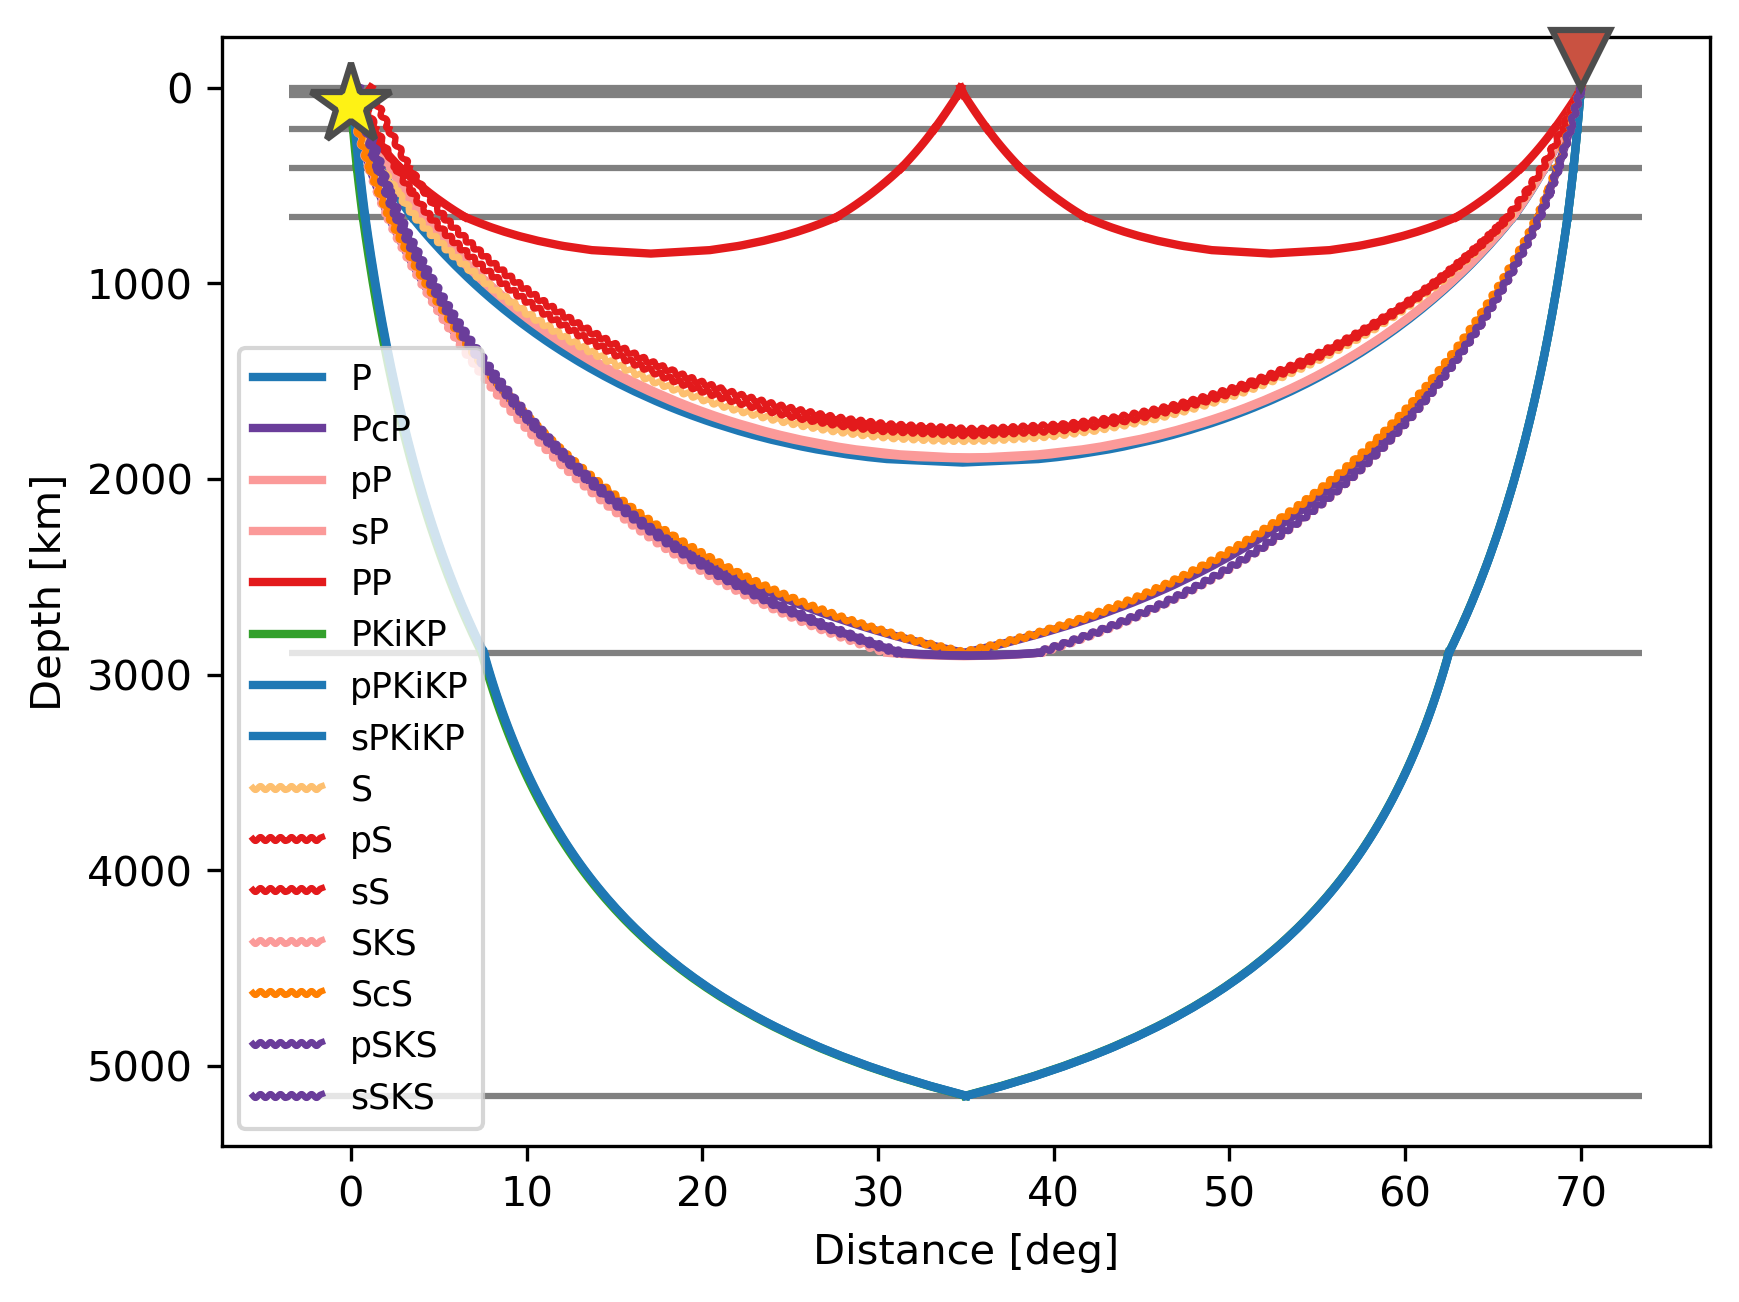

In [15]:
arribos = model.get_ray_paths(source_depth_in_km=90, distance_in_degree=70, phase_list=['ttbasic'])
fig = plt.figure(dpi=300)
arribos.plot_rays(plot_type="cartesian",plot_all=False,show=False,fig=fig,legend=True,indicate_wave_type=True)
plt.show()

Ahora, esos son los rayos para una sola estación. Necesitamos las curvas de tiempo trayecto (que nos dirán los tiempos de arribo para cualquier distancia).

<Axes: xlabel='Distance (degrees)', ylabel='Time (minutes)'>

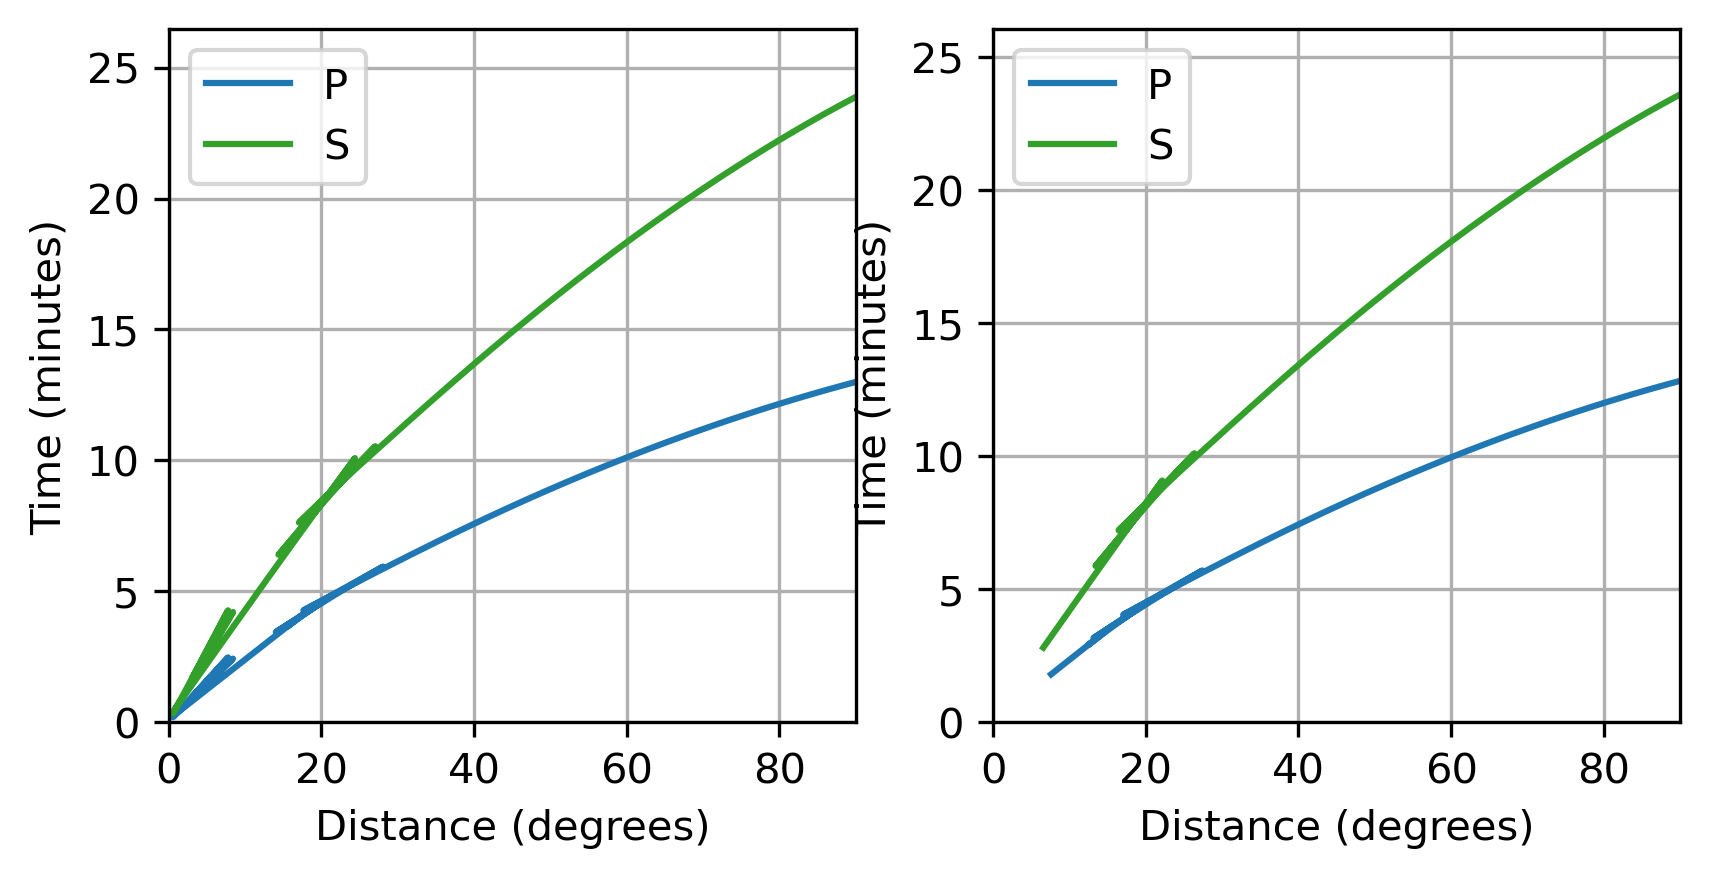

In [19]:
from obspy.taup import plot_travel_times
fig = plt.figure(dpi=300,figsize=(6.5,3))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122)
plot_travel_times(10,phase_list=['P','S'],max_degrees=90,model='iasp91',legend=True,show=False,fig=fig,ax=ax1)
plot_travel_times(90,phase_list=['P','S'],max_degrees=90,model='iasp91',legend=True,show=False,fig=fig,ax=ax2)

[Volver al índice](#0-índice)

## 5. Ejercicios <a id="5-ejercicios"></a>
1. Modelo de velocidades
Elige un modelo distinto de `iasp91` (por ejemplo, `ak135`). Observa si cambian los resultados.  

2. Tiempos de arribo
Calcula los tiempos de arribo de las fases **P** y **S** para un evento a 30 km de profundidad y 15° de distancia.  

3. Trayectorias de rayos
Dibuja la trayectoria de las fases **P** y **S** para un evento a 50 km de profundidad y 20° de distancia.  

4. Visualización
Haz un gráfico en coordenadas cartesianas con las trayectorias.  

5. Curvas tiempo-trayecto
Grafica las curvas de tiempo-trayecto para profundidades de 10 km y 90 km (fases **P** y **S**).  


### Referencias

The ObsPy Development Team (s.f.) obspy.taup - Ray theoretical travel times and paths. Recuperado de: https://docs.obspy.org/packages/obspy.taup.html